In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.linear_model import LinearRegression
from scipy import constants

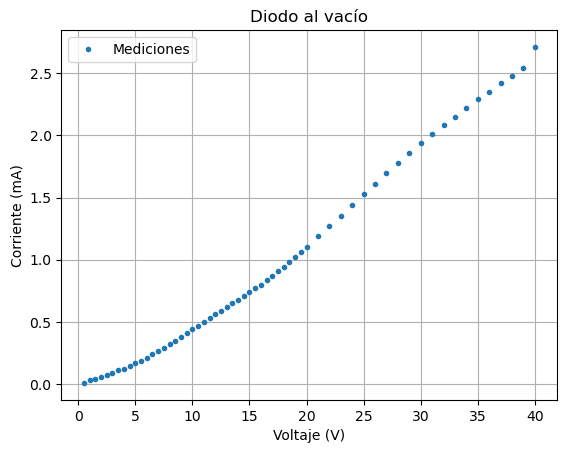

In [2]:
#Obtengo datos de la polarizacion directa
with open('P2datos.csv', mode='r') as archivo:
    ArchivoAbierto = csv.reader(archivo) #Usamos la biblioteca csv
    next(ArchivoAbierto,None)            #Me salto el primer renglón
    Ia, Va = [], []
    for renglon in ArchivoAbierto:
        Ia.append(float(renglon[0]))
        Va.append(float(renglon[1]))

#Función para graficar semilog sin problemas
def filtro_log(func_x, func_y):
    func_y_filtrada = []
    func_x_filtrada = []
    for i in range(len(func_y)):
        if func_y[i] > 0.001:
            func_y_filtrada.append(func_y[i])
            func_x_filtrada.append(func_x[i])
    return np.array(func_x_filtrada), np.array(func_y_filtrada)

plt.plot(Va,Ia,'.',label='Mediciones')
plt.title('Diodo al vacío')
plt.xlabel('Voltaje (V)'), plt.ylabel('Corriente (mA)')
#plt.axhline(y=1, color='red', linestyle='--', linewidth=0.8)
#plt.text(0.31,1.25,'I = 1')
plt.legend()
plt.grid()
plt.show()

In [3]:
#Regresion lineal en escala loglog usando sklearn
Va_filt, Ia_filt = filtro_log(Va,Ia)

Va_log = np.log(Va_filt)
Ia_log = np.log(Ia_filt)              #Para que la gráfica sea lineal
Va_reshape = np.array(Va_log).reshape(-1,1)    #predict necesita un arreglo 2D

model = LinearRegression()
model.fit(Va_reshape, Ia_log)

#Regresion en escala logaritimica
Ia_reg_log = model.predict(Va_reshape)
#Volvemos a la escala "lineal'
Ia_reg = np.exp(Ia_reg_log)

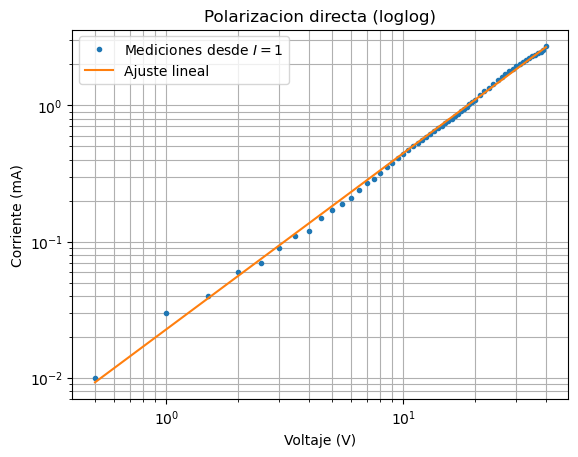

In [4]:
plt.loglog(Va_filt,Ia_filt,'.',label=r'Mediciones desde $I = 1$')
plt.plot(Va_filt,Ia_reg,label='Ajuste lineal')
plt.title('Polarizacion directa (loglog)')
plt.xlabel('Voltaje (V)'), plt.ylabel('Corriente (mA)')
plt.grid(True, which="both", ls = '-')
plt.legend()
plt.show()

In [28]:
m = model.coef_[0]     #m = pendiente = 3/2
b = model.intercept_ * 1e3  #b = ordenada al origen en A

#Datos
e0 = constants.epsilon_0
#L = 3e10       #CAMBIAR  
L = 1
ra = 0.02     #CAMBIAR
rc = 0.01    #CAMBIAR
alfa = np.log(ra/rc)
beta = alfa - (2/5)*(alfa)**2 + (11/120)*(alfa)**3 - (47/3300)*(alfa)**4

B = (8*np.pi*e0*L*np.sqrt(2))/(9*ra*(beta)**2)

razon_experimental = np.exp(2*b/B)

#Calculo exacto de razon
me = constants.m_e
e = constants.e
razon_real = e/me

print(alfa)
print(np.exp(1/B))
print('La razón REAL entre las constantes es de:', razon_real)
print('La razón experimental entre las constantes es:',razon_experimental)
print('Tenemos un error relativo:',(razon_real-razon_experimental)/razon_experimental)

0.6931471805599453
inf
La razón REAL entre las constantes es de: 175882000837.79984
La razón experimental entre las constantes es: 0.0
Tenemos un error relativo: inf


C:\Users\ivanj\AppData\Local\Temp\ipykernel_16152\2628218125.py:23: RuntimeWarning: overflow encountered in exp
  print(np.exp(1/B))
C:\Users\ivanj\AppData\Local\Temp\ipykernel_16152\2628218125.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  print('Tenemos un error relativo:',(razon_real-razon_experimental)/razon_experimental)
